<a href="https://colab.research.google.com/github/vedant-sangrame/Machine-Learning/blob/main/Prac4_ML_ASSIGNMENT1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Vedant Sangrame (CS23163)**

**ASSIGNMENT - 1**

**Aim: To build and evaluate a Decision Tree model for classification tasks and study the effect of tree depth and splitting criteria.**

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = "/content/drive/MyDrive/ML_dataset/Developer_Performance_dataset_1000 - Developer_Performance_dataset_1000.csv"
df = pd.read_csv(path)
df.head(5)

,Hours_Coding,Lines_of_Code,Bugs_Found,Bugs_Fixed,AI_Usage_Hours,Sleep_Hours,Cognitive_Load,Coffee_Intake,Stress_Level,Task_Duration_Hours,Commits,Errors,Task_Success_Rate
0,7,416,9,7,6,5.9,92,7,99,10.5,20,3,34
1,4,269,16,13,5,5.1,85,2,100,9.5,17,8,36
2,11,439,3,0,2,6.2,38,2,55,18.3,35,2,79
3,8,472,15,9,4,4.2,26,5,30,12.6,28,4,94
4,5,265,19,16,5,8.1,82,6,82,7.0,25,9,33


In [ ]:
df.describe()

,Hours_Coding,Lines_of_Code,Bugs_Found,Bugs_Fixed,AI_Usage_Hours,Sleep_Hours,Cognitive_Load,Coffee_Intake,Stress_Level,Task_Duration_Hours,Commits,Errors,Task_Success_Rate
count,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.84000,356.23400,9.876000,7.153000,2.961000,6.465800,56.933000,3.368000,66.410000,8.700100,17.253000,4.544000,56.578000
std,3.15854,188.15535,5.796052,5.468226,2.021278,1.439529,21.767506,2.342234,21.865452,5.992891,10.836901,2.820997,20.814879
min,1.00000,26.00000,0.000000,0.000000,0.000000,4.000000,20.000000,0.000000,30.000000,0.500000,1.000000,0.000000,30.000000
25%,3.00000,209.50000,5.000000,2.000000,1.000000,5.200000,38.000000,1.000000,48.000000,4.000000,9.000000,2.000000,37.000000
50%,6.00000,332.00000,10.000000,7.000000,3.000000,6.400000,57.000000,3.000000,66.000000,7.450000,14.000000,5.000000,55.500000
75%,9.00000,480.50000,15.000000,12.000000,5.000000,7.700000,76.000000,5.000000,86.000000,12.000000,23.000000,7.000000,74.000000
max,11.00000,993.00000,19.000000,19.000000,6.000000,9.000000,94.000000,7.000000,100.000000,27.500000,50.000000,9.000000,100.000000


In [ ]:
df.shape

(1000, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Hours_Coding         1000 non-null   int64  
 1   Lines_of_Code        1000 non-null   int64  
 2   Bugs_Found           1000 non-null   int64  
 3   Bugs_Fixed           1000 non-null   int64  
 4   AI_Usage_Hours       1000 non-null   int64  
 5   Sleep_Hours          1000 non-null   float64
 6   Cognitive_Load       1000 non-null   int64  
 7   Coffee_Intake        1000 non-null   int64  
 8   Stress_Level         1000 non-null   int64  
 9   Task_Duration_Hours  1000 non-null   float64
 10  Commits              1000 non-null   int64  
 11  Errors               1000 non-null   int64  
 12  Task_Success_Rate    1000 non-null   int64  
dtypes: float64(2), int64(11)
memory usage: 101.7 KB


In [ ]:
df.columns

Index(['Hours_Coding', 'Lines_of_Code', 'Bugs_Found', 'Bugs_Fixed',
       'AI_Usage_Hours', 'Sleep_Hours', 'Cognitive_Load', 'Coffee_Intake',
       'Stress_Level', 'Task_Duration_Hours', 'Commits', 'Errors',
       'Task_Success_Rate'],
      dtype='object')

In [ ]:
df.isnull()

,Hours_Coding,Lines_of_Code,Bugs_Found,Bugs_Fixed,AI_Usage_Hours,Sleep_Hours,Cognitive_Load,Coffee_Intake,Stress_Level,Task_Duration_Hours,Commits,Errors,Task_Success_Rate
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().any().any()

np.False_

In [ ]:
df.isnull().sum()

,0
Hours_Coding,0
Lines_of_Code,0
Bugs_Found,0
Bugs_Fixed,0
AI_Usage_Hours,0
Sleep_Hours,0
Cognitive_Load,0
Coffee_Intake,0
Stress_Level,0
Task_Duration_Hours,0


In [ ]:
df[df.isnull().any(axis = 1)]

,Hours_Coding,Lines_of_Code,Bugs_Found,Bugs_Fixed,AI_Usage_Hours,Sleep_Hours,Cognitive_Load,Coffee_Intake,Stress_Level,Task_Duration_Hours,Commits,Errors,Task_Success_Rate


In [ ]:
del df['Errors']
df.columns

Index(['Hours_Coding', 'Lines_of_Code', 'Bugs_Found', 'Bugs_Fixed',
       'AI_Usage_Hours', 'Sleep_Hours', 'Cognitive_Load', 'Coffee_Intake',
       'Stress_Level', 'Task_Duration_Hours', 'Commits', 'Task_Success_Rate'],
      dtype='object')

In [ ]:
df.shape

(1000, 12)

In [ ]:
before_rows = df.shape[0]
df = df.dropna()
after_rows = df.shape[0]

print("Before rows:", before_rows)
print("After rows:", after_rows)
print("Total rows dropped:", before_rows - after_rows)
print("The number of dropped rwos are {}".format(before_rows - after_rows))

Before rows: 1000
After rows: 1000
Total rows dropped: 0
The number of dropped rwos are 0


In [ ]:
df.shape

(1000, 12)

In [ ]:
clean_data = df.copy()
clean_data['high_success_rate_label'] = (clean_data['Task_Success_Rate'] > 70) * 1
print(clean_data['high_success_rate_label'])

0      0
1      0
2      1
3      1
4      0
      ..
995    1
996    1
997    1
998    0
999    1
Name: high_success_rate_label, Length: 1000, dtype: int64


In [ ]:
clean_data.columns

Index(['Hours_Coding', 'Lines_of_Code', 'Bugs_Found', 'Bugs_Fixed',
       'AI_Usage_Hours', 'Sleep_Hours', 'Cognitive_Load', 'Coffee_Intake',
       'Stress_Level', 'Task_Duration_Hours', 'Commits', 'Task_Success_Rate',
       'high_success_rate_label'],
      dtype='object')

In [ ]:
del clean_data['Task_Success_Rate']
clean_data.columns

Index(['Hours_Coding', 'Lines_of_Code', 'Bugs_Found', 'Bugs_Fixed',
       'AI_Usage_Hours', 'Sleep_Hours', 'Cognitive_Load', 'Coffee_Intake',
       'Stress_Level', 'Task_Duration_Hours', 'Commits',
       'high_success_rate_label'],
      dtype='object')

In [ ]:
X = clean_data.iloc[:, :-1]
print(X)

     Hours_Coding  Lines_of_Code  Bugs_Found  Bugs_Fixed  AI_Usage_Hours  \
0               7            416           9           7               6   
1               4            269          16          13               5   
2              11            439           3           0               2   
3               8            472          15           9               4   
4               5            265          19          16               5   
..            ...            ...         ...         ...             ...   
995            10            660          14          13               0   
996             9            484          13          11               1   
997             2            128           4           0               3   
998             8            266           5           3               1   
999             8            604          16          15               3   

     Sleep_Hours  Cognitive_Load  Coffee_Intake  Stress_Level  \
0            5.9      

In [ ]:
y = clean_data.iloc[:, -1]
print(y)

0      0
1      0
2      1
3      1
4      0
      ..
995    1
996    1
997    1
998    0
999    1
Name: high_success_rate_label, Length: 1000, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.7, test_size = 0.3, random_state = 42)

In [ ]:
X_train

,Hours_Coding,Lines_of_Code,Bugs_Found,Bugs_Fixed,AI_Usage_Hours,Sleep_Hours,Cognitive_Load,Coffee_Intake,Stress_Level,Task_Duration_Hours,Commits
541,3,178,0,0,1,8.1,28,0,39,3.8,7
440,6,226,5,2,2,5.2,21,2,30,9.9,8
482,5,388,4,1,6,5.4,68,1,74,2.8,11
422,1,176,8,3,3,6.4,84,3,98,0.8,7
778,5,340,17,15,0,6.3,24,4,42,8.1,5
...,...,...,...,...,...,...,...,...,...,...,...
106,8,236,17,15,3,6.0,61,4,73,4.0,27
270,8,228,5,3,2,8.8,23,5,30,19.2,26
860,1,102,19,14,2,5.9,51,3,62,1.4,6
435,7,189,17,12,0,8.1,26,0,45,4.1,14


In [ ]:
X_test

,Hours_Coding,Lines_of_Code,Bugs_Found,Bugs_Fixed,AI_Usage_Hours,Sleep_Hours,Cognitive_Load,Coffee_Intake,Stress_Level,Task_Duration_Hours,Commits
521,3,234,5,3,2,8.4,63,5,81,1.7,5
737,2,254,5,1,6,6.6,86,4,100,2.3,12
740,5,266,13,9,4,6.4,84,3,84,6.5,14
660,5,140,3,0,0,8.1,60,3,76,11.7,20
411,8,810,2,0,6,8.0,43,5,55,10.4,30
...,...,...,...,...,...,...,...,...,...,...,...
468,4,168,8,6,3,4.4,60,5,73,7.2,15
935,4,210,2,0,2,7.9,34,0,45,3.7,14
428,9,646,8,2,2,8.3,94,7,100,11.5,11
7,3,234,5,1,6,5.8,78,2,86,2.9,15


In [ ]:
y_train

,high_success_rate_label
541,1
440,1
482,0
422,0
778,1
...,...
106,0
270,1
860,0
435,1


In [ ]:
y_test

,high_success_rate_label
521,0
737,0
740,0
660,0
411,1
...,...
468,0
935,1
428,0
7,0


In [ ]:
from sklearn.preprocessing import StandardScaler
scaling = StandardScaler()
X_train = scaling.fit_transform(X_train)
X_test = scaling.transform(X_test)

In [ ]:
X_train

array([[-0.87753895, -0.93722361, -1.71908448, ..., -1.20580609,
        -0.79869049, -0.9426044 ],
       [ 0.06701861, -0.68062368, -0.84569274, ..., -1.61110825,
         0.21925071, -0.85171967],
       [-0.24783391,  0.18540109, -1.02037109, ...,  0.37036897,
        -0.96556609, -0.57906551],
       ...,
       [-1.50724399, -1.34350684,  1.59980412, ..., -0.17003391,
        -1.19919194, -1.03348912],
       [ 0.38187113, -0.87841946,  1.25044743, ..., -0.93560465,
        -0.7486278 , -0.30641135],
       [ 1.32642868, -0.38125709, -1.02037109, ...,  0.64057041,
         0.33606363,  2.23836085]])

In [ ]:
humidity_classifier = DecisionTreeClassifier(max_leaf_nodes = 10, random_state = 0)
humidity_classifier.fit(X_train, y_train)

DecisionTreeClassifier(max_leaf_nodes=10, random_state=0)

[Text(0.5454545454545454, 0.9166666666666666, 'x[6] <= -0.535\ngini = 0.439\nsamples = 700\nvalue = [472, 228]'),
 Text(0.2727272727272727, 0.75, 'x[8] <= -1.048\ngini = 0.257\nsamples = 244\nvalue = [37, 207]'),
 Text(0.40909090909090906, 0.8333333333333333, 'True  '),
 Text(0.18181818181818182, 0.5833333333333334, 'gini = 0.042\nsamples = 141\nvalue = [3, 138]'),
 Text(0.36363636363636365, 0.5833333333333334, 'x[4] <= -0.745\ngini = 0.442\nsamples = 103\nvalue = [34, 69]'),
 Text(0.2727272727272727, 0.4166666666666667, 'x[6] <= -0.9\ngini = 0.469\nsamples = 32\nvalue = [20, 12]'),
 Text(0.18181818181818182, 0.25, 'x[1] <= -0.983\ngini = 0.469\nsamples = 16\nvalue = [6, 10]'),
 Text(0.09090909090909091, 0.08333333333333333, 'gini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.2727272727272727, 0.08333333333333333, 'gini = 0.298\nsamples = 11\nvalue = [2, 9]'),
 Text(0.36363636363636365, 0.25, 'gini = 0.219\nsamples = 16\nvalue = [14, 2]'),
 Text(0.45454545454545453, 0.4166666666666667

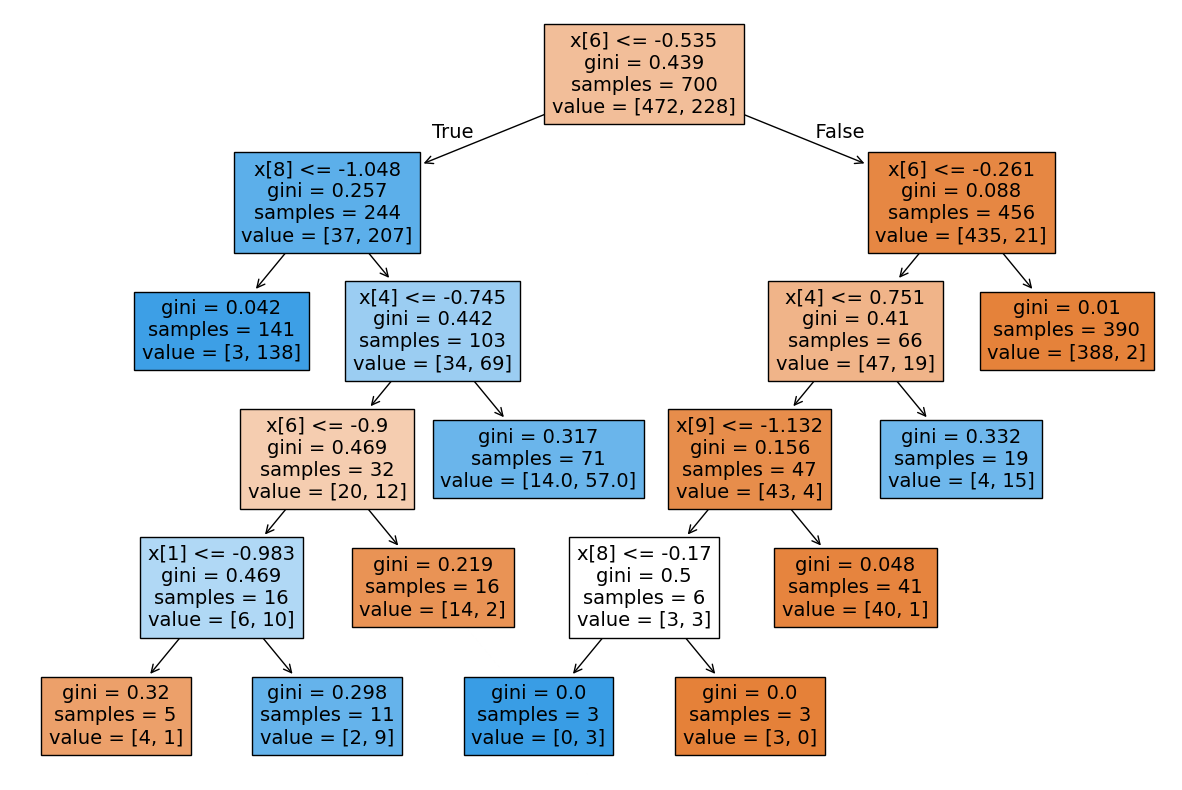

In [ ]:
import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize = (15, 10))
tree.plot_tree(humidity_classifier, filled = True)

In [ ]:
y_pred = humidity_classifier.predict(X_test)
print(y_pred)

[0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 0 0 1 1 1 0 0 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1
 1 0 0 0 1 1 0 0 1 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 1 1 0 0
 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 1 0 0 0
 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 1 1 0 0 0 1 1 0 1 1 1 0 0 0 0 0
 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 1 1 0 0 1
 1 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 1 0 1 0 1 0 0 1 1 0 0 0 0 0 1 1 1 0
 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0 0 0 0 1 0 0 1 0 0 0 0
 1 0 0 0]


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [ ]:
print(confusion_matrix(y_pred, y_test))

[[209   7]
 [ 10  74]]


In [ ]:
accuracy = accuracy_score(y_pred, y_test)
print(accuracy)

0.9433333333333334


In [ ]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       216
           1       0.91      0.88      0.90        84

    accuracy                           0.94       300
   macro avg       0.93      0.92      0.93       300
weighted avg       0.94      0.94      0.94       300

